In [1]:
# Import the libraries required for this project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

# Display all columns when viewing dataframes
pd.set_option("display.max_columns", None)

# Load the dataset
df = pd.read_csv("demand_forecasting.csv")

# Display the first five rows
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [2]:
# Check the number of rows and columns
print(f"Dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.")

# Display column names and data types
df.info()

Dataset contains 76,000 rows and 16 columns.
<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand             

In [3]:
# 1. Convert Date from text to a proper datetime format
df["Date"] = pd.to_datetime(df["Date"])

# 2. Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# 3. Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# 4. Check the date range
print("\nStart date:", df["Date"].min().date())
print("End date:", df["Date"].max().date())

# 5. Check the number of unique dates, stores, and products
print("\nUnique dates:", df["Date"].nunique())
print("Unique stores:", df["Store ID"].nunique())
print("Unique products:", df["Product ID"].nunique())

Duplicate rows: 0

Missing values per column:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

Start date: 2022-01-01
End date: 2024-01-30

Unique dates: 760
Unique stores: 5
Unique products: 20


In [4]:
# Summary statistics for the target variable
df["Demand"].describe()

count    76000.000000
mean       104.317158
std         46.964801
min          4.000000
25%         71.000000
50%        100.000000
75%        133.000000
max        430.000000
Name: Demand, dtype: float64

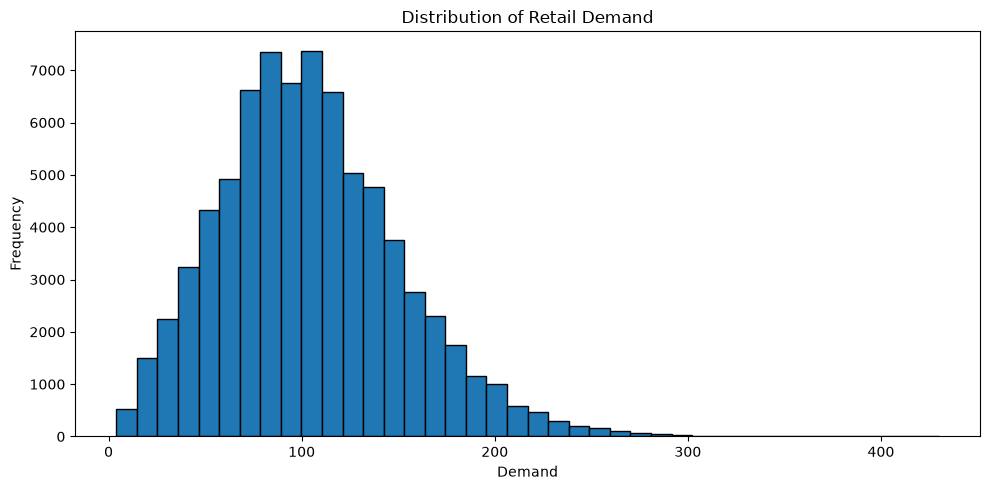

In [5]:
# Visualize the distribution of demand
plt.figure(figsize=(10, 5))

plt.hist(df["Demand"], bins=40, edgecolor="black")

plt.title("Distribution of Retail Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Demand Distribution Analysis

The histogram shows a **unimodal, positively skewed distribution** of retail demand. Most observations are concentrated in the middle of the distribution, while a smaller number of observations extend toward higher demand values.


In [6]:
# Calculate key statistics for demand
demand_stats = df["Demand"].agg(
    ["mean", "median", "std", "min", "max"]
)

print(demand_stats)

# Calculate the 25th and 75th percentiles
print("\nDemand percentiles:")
print(df["Demand"].quantile([0.25, 0.50, 0.75]))

mean      104.317158
median    100.000000
std        46.964801
min         4.000000
max       430.000000
Name: Demand, dtype: float64

Demand percentiles:
0.25     71.0
0.50    100.0
0.75    133.0
Name: Demand, dtype: float64


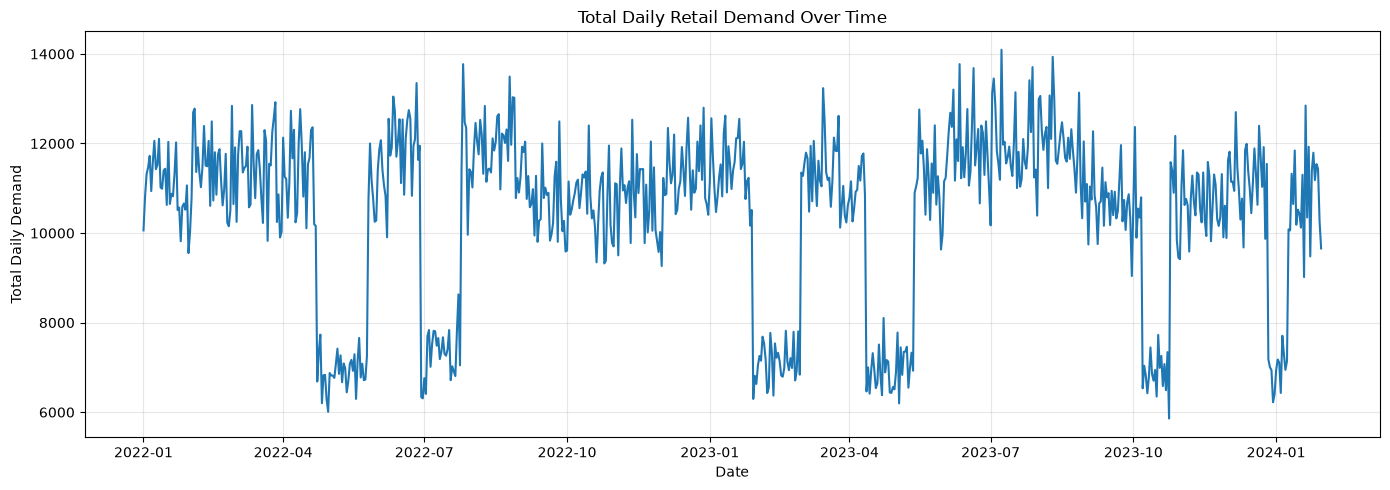

In [7]:
# Calculate total demand across all stores and products for each day
daily_demand = (
    df.groupby("Date")["Demand"]
    .sum()
    .sort_index()
)

# Plot daily total demand over time
plt.figure(figsize=(14, 5))

plt.plot(daily_demand.index, daily_demand.values)

plt.title("Total Daily Retail Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Daily Demand")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Daily Demand Trends Over Time

Daily demand was aggregated across all stores and products to examine changes over the period from January 2022 to January 2024.

The plot alone cannot establish the causes of these dips or confirm annual seasonality. Further analysis will help determine whether calendar-based features improve forecasting performance.


Date
Monday       10342.33
Tuesday      10366.52
Wednesday    10519.20
Thursday     10440.83
Friday       10439.44
Saturday     10448.40
Sunday       10466.23
Name: Demand, dtype: float64


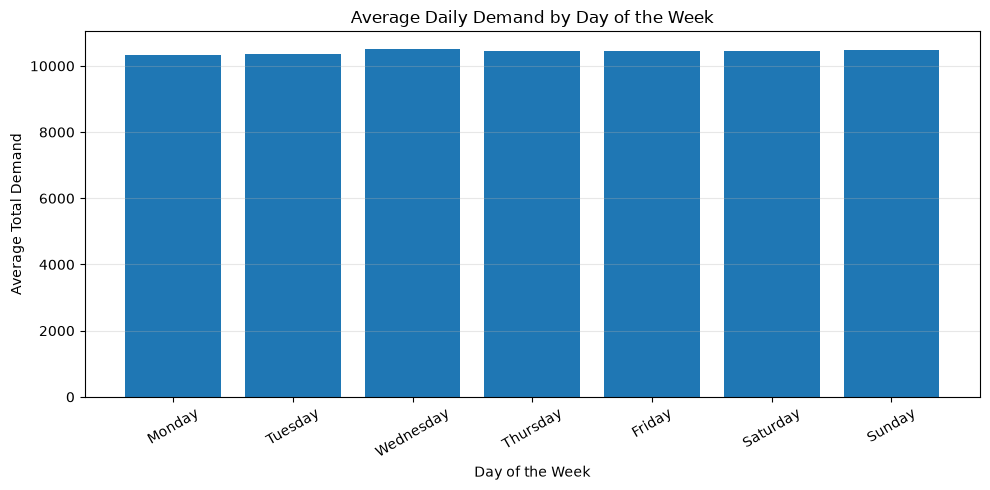

In [8]:
# Calculate average total demand for each weekday
weekday_demand = daily_demand.groupby(
    daily_demand.index.day_name()
).mean()

# Arrange weekdays in calendar order
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_demand = weekday_demand.reindex(weekday_order)

print(weekday_demand.round(2))

# Visualize average demand by weekday
plt.figure(figsize=(10, 5))

plt.bar(weekday_demand.index, weekday_demand.values)

plt.title("Average Daily Demand by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Total Demand")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Weekday Demand Analysis

Average daily demand was calculated for each day of the week using total demand aggregated across all stores and products.

The bar chart suggests that average demand is relatively consistent from Monday through Sunday, with no obvious large weekday or weekend differences.

This analysis is an initial visual assessment, not a statistical test of weekday effects.


January      10604.00
February      9288.25
March        11361.39
April         9281.67
May           8652.11
June         11734.60
July         10156.16
August       11980.34
September    10743.15
October       9555.73
November     10754.23
December     10900.32
Name: Demand, dtype: float64


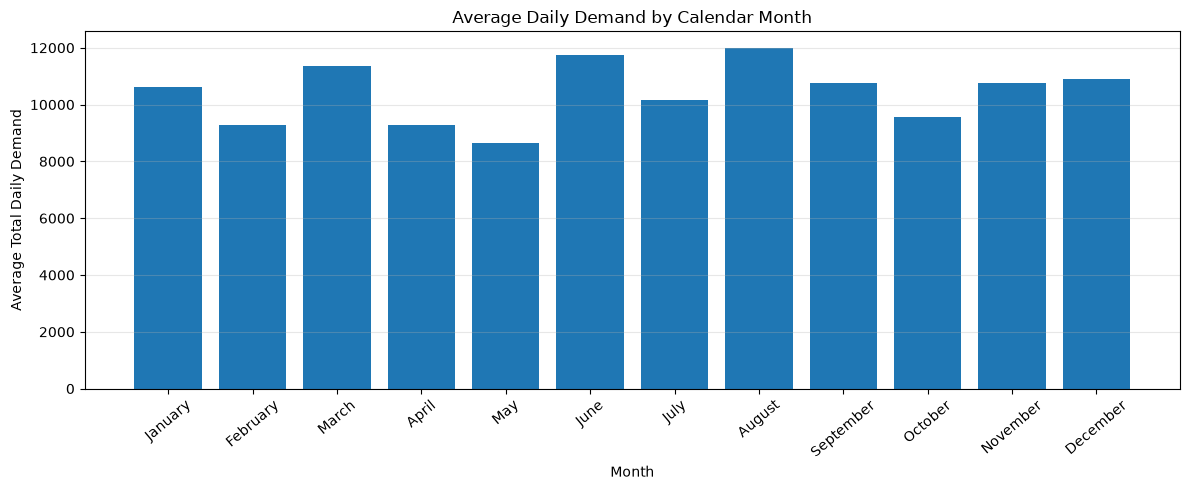

In [9]:
# Calculate average total demand for each calendar month
monthly_demand = daily_demand.groupby(
    daily_demand.index.month
).mean()

month_names = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_demand.index = [
    month_names[month - 1] for month in monthly_demand.index
]

print(monthly_demand.round(2))

# Visualize average demand by month
plt.figure(figsize=(12, 5))

plt.bar(monthly_demand.index, monthly_demand.values)

plt.title("Average Daily Demand by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Average Total Daily Demand")
plt.xticks(rotation=40)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### Monthly Demand Analysis

Average daily demand was compared across calendar months to investigate potential seasonal variation.

These results indicate variation in average demand across months, but they do not establish a recurring annual seasonal pattern. Further time-based validation is needed to determine whether month-related features improve forecast accuracy.


In [10]:
# Create a time-series dataset with one row per date
forecast_data = daily_demand.to_frame(name="Actual_Demand")

# Add historical demand features
forecast_data["Demand_Lag_1"] = forecast_data["Actual_Demand"].shift(1)
forecast_data["Demand_Lag_7"] = forecast_data["Actual_Demand"].shift(7)

# Add rolling averages using only previous days
forecast_data["Rolling_Mean_7"] = (
    forecast_data["Actual_Demand"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

forecast_data["Rolling_Mean_30"] = (
    forecast_data["Actual_Demand"]
    .shift(1)
    .rolling(window=30)
    .mean()
)

# Add calendar features
forecast_data["Day_of_Week"] = forecast_data.index.dayofweek
forecast_data["Month"] = forecast_data.index.month

# Remove rows without sufficient historical data
forecast_data = forecast_data.dropna()

forecast_data.head()

,Actual_Demand,Demand_Lag_1,Demand_Lag_7,Rolling_Mean_7,Rolling_Mean_30,Day_of_Week,Month
Date,,,,,,,
2022-01-31,10028,9553.0,10570.0,10395.714286,11050.533333,0,1
2022-02-01,10791,10028.0,9818.0,10318.285714,11049.466667,1,2
2022-02-02,12698,10791.0,10584.0,10457.285714,11048.700000,2,2
2022-02-03,12779,12698.0,10659.0,10759.285714,11094.733333,3,2
2022-02-04,11363,12779.0,10522.0,11062.142857,11138.400000,4,2


## Preparing the Forecasting Dataset

The dataset now includes historical demand and calendar features for forecasting. These features will be used to predict daily demand, with earlier dates used for training and later dates reserved for testing.

In [11]:
# Split the data chronologically
split_index = int(len(forecast_data) * 0.8)

train_data = forecast_data.iloc[:split_index]
test_data = forecast_data.iloc[split_index:]

# Select input features and target
features = [
    "Demand_Lag_1",
    "Demand_Lag_7",
    "Rolling_Mean_7",
    "Rolling_Mean_30",
    "Day_of_Week",
    "Month"
]

X_train = train_data[features]
y_train = train_data["Actual_Demand"]

X_test = test_data[features]
y_test = test_data["Actual_Demand"]

print("Training period:", train_data.index.min().date(), "to", train_data.index.max().date())
print("Testing period:", test_data.index.min().date(), "to", test_data.index.max().date())
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training period: 2022-01-31 to 2023-09-06
Testing period: 2023-09-07 to 2024-01-30
Training rows: 584
Testing rows: 146


## Baseline Model

A baseline forecast provides a simple reference for evaluating the machine learning model. This baseline uses the previous day's demand as the prediction for the current day. The machine learning model should perform better than this simple approach to demonstrate its value.

In [12]:
# Use the previous day's demand as the baseline prediction
baseline_predictions = X_test["Demand_Lag_1"]

# Evaluate baseline performance
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline MAE: 886.93
Baseline RMSE: 1240.88


In [13]:
# Train the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train, y_train)

# Predict demand for the test period
rf_predictions = rf_model.predict(X_test)

# Evaluate model performance
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")

Random Forest MAE: 725.62
Random Forest RMSE: 1044.96


In [14]:
# Compare model performance
results = pd.DataFrame({
    "Model": ["Baseline", "Random Forest"],
    "MAE": [baseline_mae, rf_mae],
    "RMSE": [baseline_rmse, rf_rmse]
})

results


,Model,MAE,RMSE
0,Baseline,886.931507,1240.880289
1,Random Forest,725.622170,1044.962216


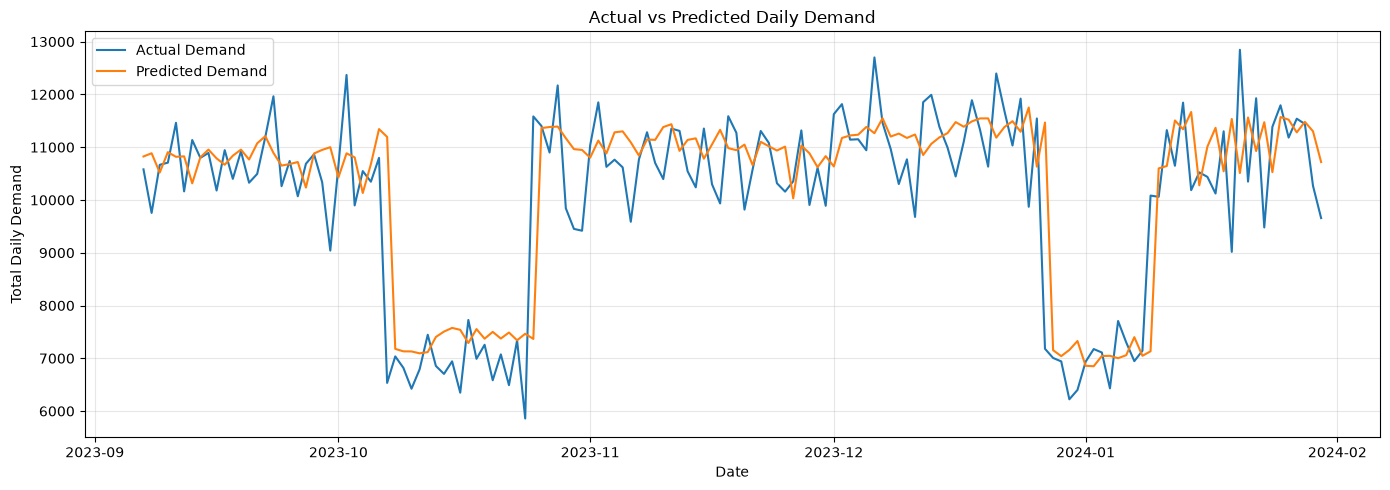

In [15]:
# Compare actual and predicted demand
plt.figure(figsize=(14, 5))

plt.plot(y_test.index, y_test.values, label="Actual Demand")
plt.plot(y_test.index, rf_predictions, label="Predicted Demand")

plt.title("Actual vs Predicted Daily Demand")
plt.xlabel("Date")
plt.ylabel("Total Daily Demand")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

           Feature  Importance
0     Demand_Lag_1    0.815061
2   Rolling_Mean_7    0.050924
3  Rolling_Mean_30    0.048667
1     Demand_Lag_7    0.039465
5            Month    0.029573
4      Day_of_Week    0.016311


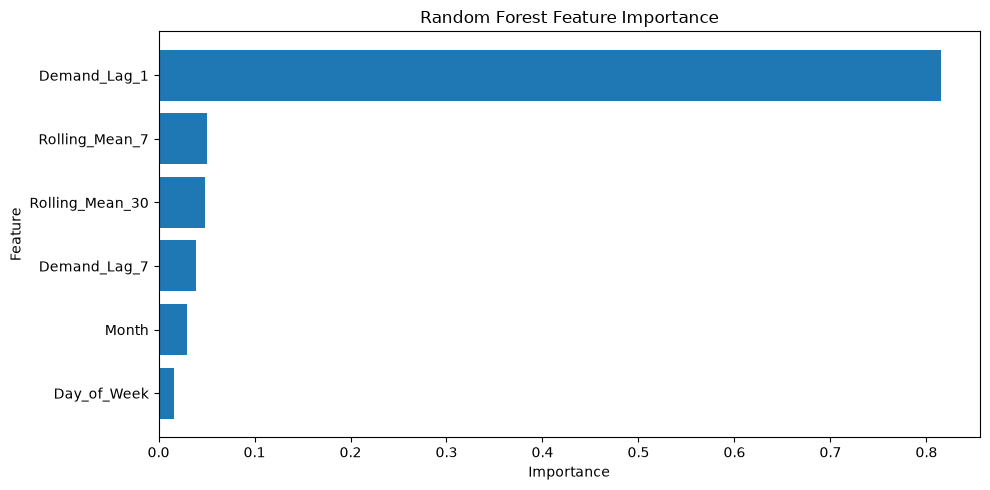

In [16]:
# Calculate and display feature importance
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 5))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Feature Importance Analysis

The previous day's demand is the most influential feature, with an importance score of around 81.5%. The 7-day and 30-day rolling averages also contribute to the predictions, while month and day of the week have smaller contributions. This suggests that recent demand is more useful for forecasting than calendar information in this model.

## Conclusion

This project explored retail demand patterns and developed a Random Forest model to forecast daily demand. The model achieved an MAE of 725.62 and an RMSE of 1044.96, outperforming the baseline model. Recent demand was the most influential feature, highlighting the importance of historical patterns in forecasting. Further improvements could include testing other models, tuning hyperparameters, and adding more relevant features.